# СӨЖ 23: Модель Интерпретациясы. SHAP және LIME

## Студентке арналған нұсқаулық

Бұл үй жұмысы модель интерпретациясының екі маңызды әдісін — SHAP пен LIME-ді — өз бетіңізше зерттеуге арналған. Ноутбуктің бірінші жартысы (деректерді жүктеу, өңдеу, модель оқыту) дайын берілген. Сіздің міндетіңіз — SHAP және LIME бөлімдерін өз бетіңізше толтыру.

**Орындау тәртібі:**

- Барлық ұяшықтарды жоғарыдан төмен ретімен іске қосыңыз
- `# ТАП:` деген жазуды тапсырма белгісі ретінде қабылдаңыз
- `# КЕҢЕС:` деген жазуды нұсқаулық ретінде қолданыңыз
- Markdown ұяшықтарындағы `[ЖАУАБЫҢЫЗДЫ ОСЫ ЖЕР ЖАЗЫҢЫЗ]` орындарын толтырыңыз

**Бағалау критерийлері:**

- SHAP кодының дұрыстығы
- LIME кодының дұрыстығы
- Нәтижелердің түсіндірмесі
- Салыстырмалы талдау



## Датасет туралы мәлімет: Heart Disease (Жүрек ауруы)

Бұл үй жұмысында **UCI Heart Disease** датасеті қолданылады. Бұл датасет Cleveland клиникасынан жиналған нақты медициналық деректер болып табылады. Мақсат — пациенттің жүрек ауруы бар-жоғын болжау.

Датасет медицина саласында интерпретация өте маңызды болатын жақсы мысал: дәрігер модельдің неге осындай шешім қабылдағанын білуі керек.

**Белгілер тізімі:**
- `age` — жас
- `sex` — жынысы (1 = ер, 0 = әйел)
- `cp` — кеуде ауруының түрі (0–3)
- `trestbps` — демалыстағы қан қысымы
- `chol` — холестерин деңгейі
- `fbs` — ашқарын қандағы қант (1 = жоғары)
- `restecg` — ЭКГ нәтижесі (0–2)
- `thalach` — максималды жүрек соғу жиілігі
- `exang` — жаттығудан туындаған стенокардия (1 = иә)
- `oldpeak` — ST депрессиясы
- `slope` — ST сегментінің еңісі
- `ca` — флюороскопиямен анықталған тамыр саны (0–3)
- `thal` — таллий стресс-тесті нәтижесі
- `target` — жүрек ауруы бар-жоғы (1 = бар, 0 = жоқ)



## 1-Бөлім. Кітапханаларды Орнату және Импорттау

Бұл бөлімді өзгертпеңіз. Тек іске қосыңыз.

In [1]:
# Қажетті кітапханаларды орнату
import subprocess, sys

def install_if_missing(package):
    try:
        __import__(package)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

for pkg in ["shap", "lime", "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"]:
    install_if_missing(pkg)

print("Барлық кітапханалар дайын.")

Барлық кітапханалар дайын.


In [2]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

import shap
import lime
import lime.lime_tabular

RANDOM_STATE = 42
TEST_SIZE    = 0.20

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

print("Кітапханалар импортталды.")
print(f"SHAP нұсқасы : {shap.__version__}")
print(f"Pandas нұсқасы: {pd.__version__}")

Кітапханалар импортталды.
SHAP нұсқасы : 0.52.0
Pandas нұсқасы: 2.2.2



## 2-Бөлім. Деректерді Жүктеу

Датасет GitHub Raw сілтемесі арқылы автоматты жүктеледі. Бұл ұяшықты өзгертпеңіз.

In [3]:
# UCI Heart Disease датасетін жүктеу
URL = "https://raw.githubusercontent.com/dsrscientist/dataset1/master/heart.csv"

try:
    df = pd.read_csv(URL)
    print(f"Датасет сәтті жүктелді.")
except Exception:
    # Балама сілтеме
    ALT = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
    df = pd.read_csv(ALT)
    print(f"Балама сілтемеден жүктелді.")

print(f"Жазба саны  : {len(df):,}")
print(f"Баған саны  : {df.shape[1]}")
df.head()

Балама сілтемеден жүктелді.
Жазба саны  : 303
Баған саны  : 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


---

## 3-Бөлім. Деректерді Зерттеу (EDA)

Бұл бөлімді өзгертпеңіз. Нәтижелерді мұқият оқып шығыңыз — SHAP/LIME бөлімдерінде олар пайдалы болады.

In [4]:
# Деректердің жалпы ақпараты
print("Деректер түрлері:")
print(df.dtypes)
print(f"\nЖетіспейтін мән саны: {df.isnull().sum().sum()}")
print("\nСандық статистика:")
df.describe().round(2)

Деректер түрлері:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Жетіспейтін мән саны: 0

Сандық статистика:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00
mean,54.37,0.68,0.97,131.62,246.26,0.15,0.53,149.65,0.33,1.04,1.40,0.73,2.31,0.54
std,9.08,0.47,1.03,17.54,51.83,0.36,0.53,22.91,0.47,1.16,0.62,1.02,0.61,0.50
min,29.00,0.00,0.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,47.50,0.00,0.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,2.00,0.00
50%,55.00,1.00,1.00,130.00,240.00,0.00,1.00,153.00,0.00,0.80,1.00,0.00,2.00,1.00
75%,61.00,1.00,2.00,140.00,274.50,0.00,1.00,166.00,1.00,1.60,2.00,1.00,3.00,1.00
max,77.00,1.00,3.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,2.00,4.00,3.00,1.00


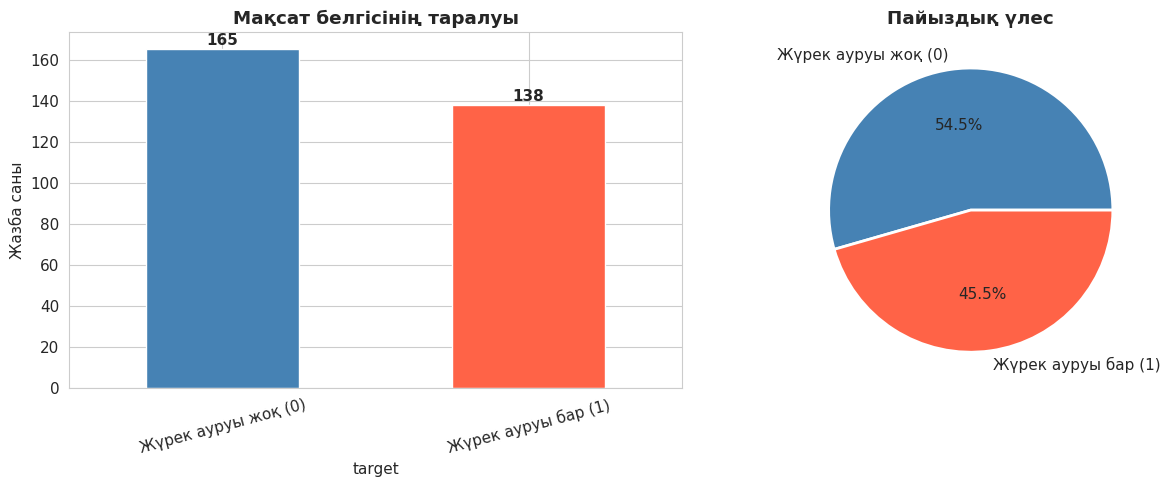

In [5]:
# Мақсат белгісінің таралуы
target_counts = df['target'].value_counts()
labels = ['Жүрек ауруы жоқ (0)', 'Жүрек ауруы бар (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

target_counts.plot(kind='bar', ax=axes[0],
                   color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Мақсат белгісінің таралуы', fontweight='bold')
axes[0].set_xticklabels(labels, rotation=15)
axes[0].set_ylabel('Жазба саны')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(target_counts, labels=labels, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'],
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Пайыздық үлес', fontweight='bold')

plt.tight_layout()
plt.show()

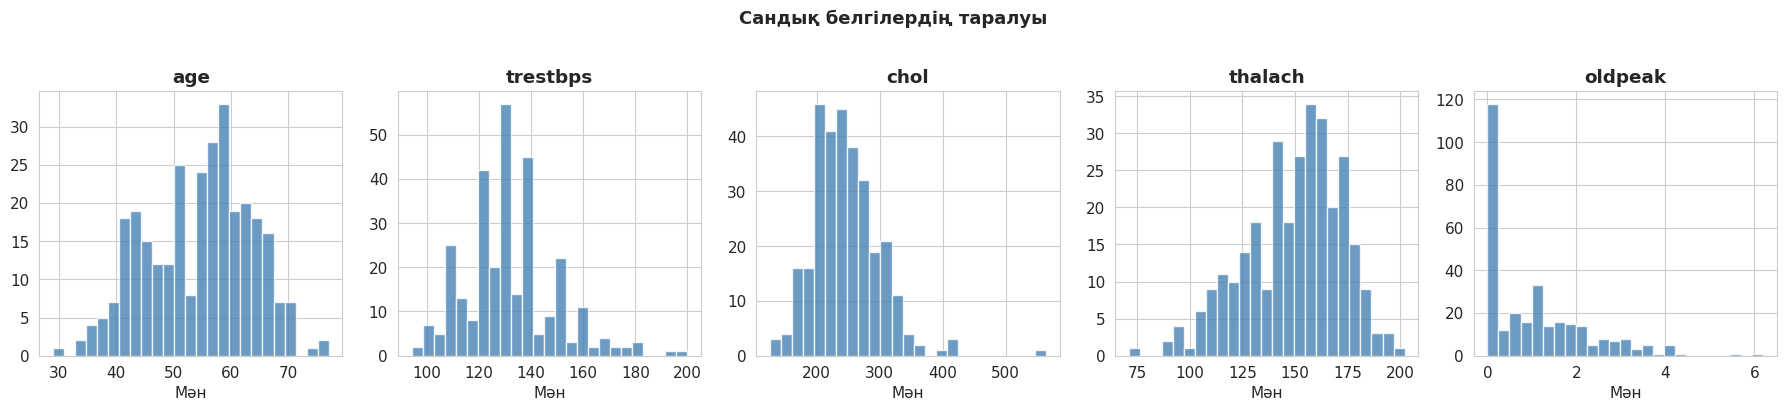

In [6]:
# Сандық белгілердің таралу гистограммалары
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    df[col].hist(bins=25, ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Мән')
plt.suptitle('Сандық белгілердің таралуы', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

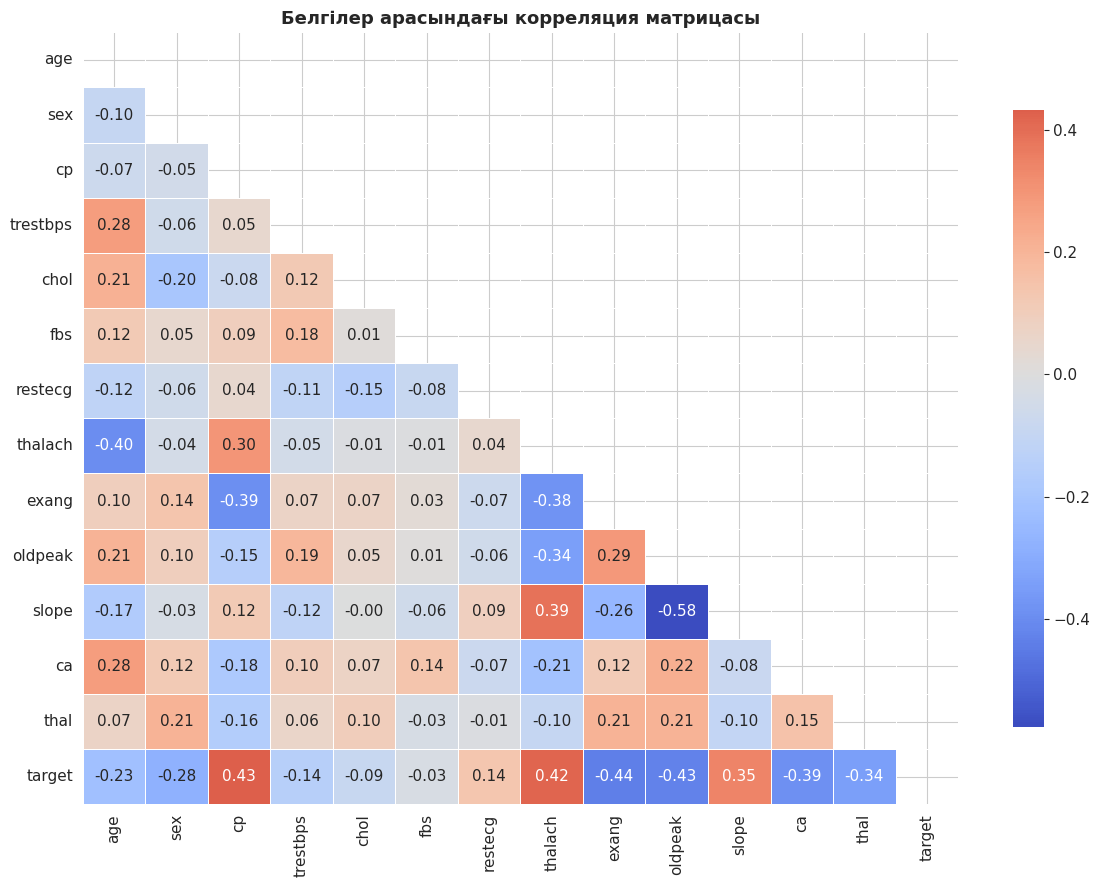

In [7]:
# Корреляция матрицасы
plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            cbar_kws={'shrink': 0.8})
plt.title('Белгілер арасындағы корреляция матрицасы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

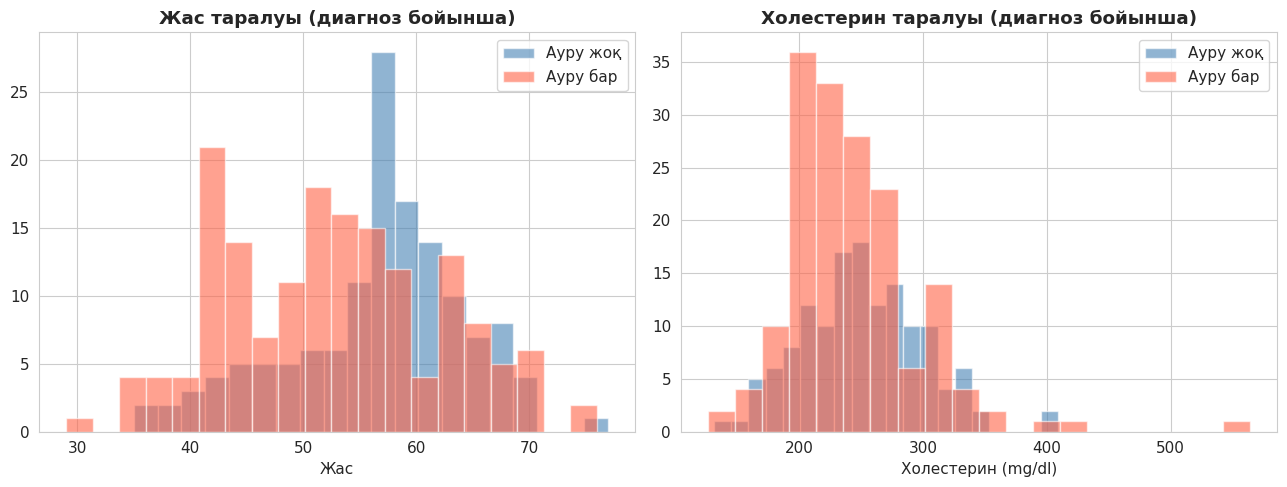

In [8]:
# Жүрек ауруы бойынша жас пен холестерин байланысы
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for val, color, label in [(0, 'steelblue', 'Ауру жоқ'), (1, 'tomato', 'Ауру бар')]:
    subset = df[df['target'] == val]
    axes[0].hist(subset['age'], bins=20, alpha=0.6, color=color, label=label, edgecolor='white')
    axes[1].hist(subset['chol'], bins=20, alpha=0.6, color=color, label=label, edgecolor='white')

axes[0].set_title('Жас таралуы (диагноз бойынша)', fontweight='bold')
axes[0].set_xlabel('Жас')
axes[0].legend()

axes[1].set_title('Холестерин таралуы (диагноз бойынша)', fontweight='bold')
axes[1].set_xlabel('Холестерин (mg/dl)')
axes[1].legend()

plt.tight_layout()
plt.show()



## 4-Бөлім. Деректерді Алдын Ала Өңдеу

Бұл бөлімді өзгертпеңіз.

In [9]:
# Жетіспейтін мәндерді тексеру
missing = df.isnull().sum()
print("Жетіспейтін мәндер:")
print(missing[missing > 0] if missing.sum() > 0 else "Жетіспейтін мән жоқ.")

Жетіспейтін мәндер:
Жетіспейтін мән жоқ.


In [10]:
# Белгілер мен мақсат белгісін бөлу
FEATURE_COLS = [c for c in df.columns if c != 'target']
TARGET_COL   = 'target'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

# Оқыту / тест бөлу
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Оқыту жиынтығы : {X_train.shape[0]} жазба")
print(f"Тест жиынтығы  : {X_test.shape[0]} жазба")
print(f"Белгілер саны  : {len(FEATURE_COLS)}")
print(f"Белгілер       : {FEATURE_COLS}")

Оқыту жиынтығы : 242 жазба
Тест жиынтығы  : 61 жазба
Белгілер саны  : 13
Белгілер       : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']




## 5-Бөлім. Модельді Оқыту

Бұл бөлімді өзгертпеңіз. Random Forest классификаторы оқытылады.

In [11]:
# Random Forest модельін оқыту
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    min_samples_split=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Модель оқытылды.")

Модель оқытылды.


In [12]:
# Модель өнімділігін бағалау
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"Дәлдік (Accuracy): {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC           : {roc_auc_score(y_test, y_prob):.4f}")
print("\nЖіктеу есебі:")
print(classification_report(y_test, y_pred,
                             target_names=['Ауру жоқ (0)', 'Ауру бар (1)']))

Дәлдік (Accuracy): 0.8197
ROC-AUC           : 0.9058

Жіктеу есебі:
              precision    recall  f1-score   support

Ауру жоқ (0)       0.95      0.64      0.77        28
Ауру бар (1)       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



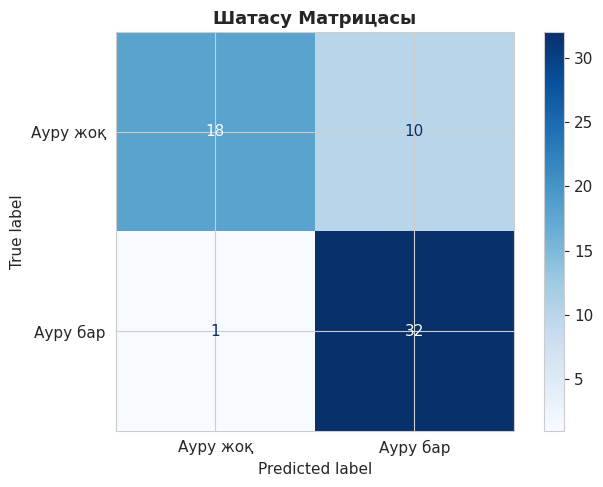

In [13]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_estimator(
    model, X_test, y_test,
    display_labels=['Ауру жоқ', 'Ауру бар'],
    cmap='Blues', ax=ax
)
ax.set_title('Шатасу Матрицасы', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

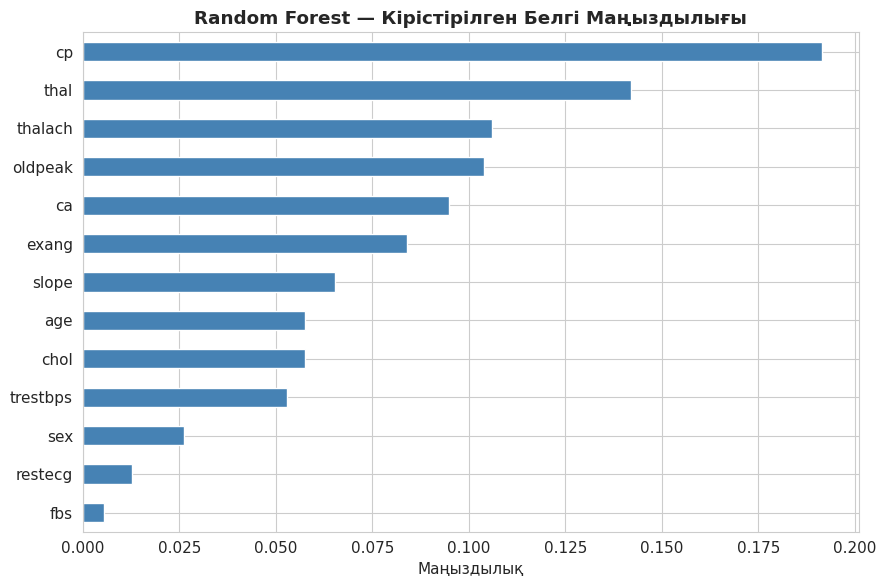


Маңыздылығы жоғары 5 белгі:
cp         0.191417
thal       0.142103
thalach    0.105931
oldpeak    0.103820
ca         0.094738
dtype: float64


In [14]:
# Sklearn-ның кірістірілген белгі маңыздылығы (салыстыру үшін сақтаңыз)
feat_imp = pd.Series(model.feature_importances_, index=FEATURE_COLS)
feat_imp_sorted = feat_imp.sort_values(ascending=True)

plt.figure(figsize=(9, 6))
feat_imp_sorted.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Кірістірілген Белгі Маңыздылығы', fontweight='bold')
plt.xlabel('Маңыздылық')
plt.tight_layout()
plt.show()

print("\nМаңыздылығы жоғары 5 белгі:")
print(feat_imp.sort_values(ascending=False).head())


## 6-Бөлім. Талдауға арналған Үлгілерді Дайындау

Бұл бөлімді өзгертпеңіз. Жергілікті интерпретация үшін екі үлгі таңдалады.

In [15]:
# Жоғары ықтималдықпен болжалған ауру бар үлгі
probs = model.predict_proba(X_test)[:, 1]
idx_sick  = np.argmax(probs)          # ауру бар болжамы ең жоғары
idx_healthy = np.argmin(probs)        # ауру жоқ болжамы ең жоғары

sample_sick    = X_test.iloc[[idx_sick]]
sample_healthy = X_test.iloc[[idx_healthy]]

print("Ауру БАР болжамы алынған пациент:")
print(f"  Нақты диагноз    : {y_test.iloc[idx_sick]}")
print(f"  Болжам ықтималдығы: {probs[idx_sick]:.4f}")

print("\nАуру ЖОҚ болжамы алынған пациент:")
print(f"  Нақты диагноз    : {y_test.iloc[idx_healthy]}")
print(f"  Болжам ықтималдығы: {probs[idx_healthy]:.4f}")

Ауру БАР болжамы алынған пациент:
  Нақты диагноз    : 1
  Болжам ықтималдығы: 0.9802

Ауру ЖОҚ болжамы алынған пациент:
  Нақты диагноз    : 0
  Болжам ықтималдығы: 0.0387


# СТУДЕНТ ТАПСЫРМАЛАРЫ

Осы жерден бастап барлық ұяшықтарды сіз толтыруыңыз керек.

## 7-Бөлім. SHAP Әдісі (30 балл)

### SHAP дегеніміз не?

SHAP (SHapley Additive exPlanations) — модельдің белгілі бір болжамды неге жасағанын түсіндіруге көмектесетін математикалық әдіс. Ойын теориясынан алынған: бірлесіп жұмыс жасаған «ойыншылар» (белгілер) нәтижеге (болжамға) қаншалықты үлес қосқанын есептейді.

SHAP мәні оң болса ол белгі болжамды арттырады (ауру бар ықтималдығын жоғарылатады), теріс болса болжамды азайтады.

**Пайдалы сілтемелер:**
- Ресми құжаттама: https://shap.readthedocs.io
- SHAP GitHub: https://github.com/slundberg/shap

### 7.1-Тапсырма. SHAP Explainer жасау (5 балл)

Random Forest — ағашқа негізделген модель. Сондықтан `shap.TreeExplainer` қолданыңыз.

In [16]:
explainer = shap.TreeExplainer(model)
shap_all = explainer.shap_values(X_test)

if type(shap_all) == list:
    shap_values = shap_all[1]
else:
    shap_values = shap_all[:, :, 1]

print(np.array(shap_values).shape)
print("SHAP ready")


(61, 13)
SHAP ready


### 7.2-Тапсырма. Жаһандық интерпретация — Summary Plot (10 балл)

Summary Plot — барлық деректер бойынша белгілердің маңыздылығын көрсетеді. Екі түрі бар:
- `plot_type='bar'` — жай жолақтық диаграмма (маңыздылық дәрежесі)
- `plot_type='dot'` немесе жай `shap.summary_plot()` — Beeswarm (нүктелі диаграмма, бағыты да көрсетіледі)

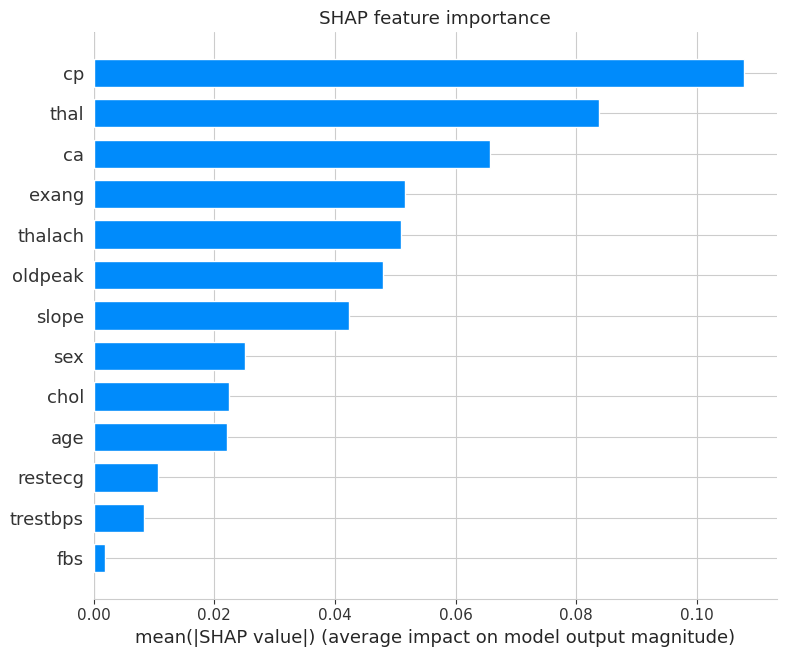

In [17]:
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type='bar', feature_names=FEATURE_COLS, show=False)
plt.title('SHAP feature importance')
plt.tight_layout()
plt.show()


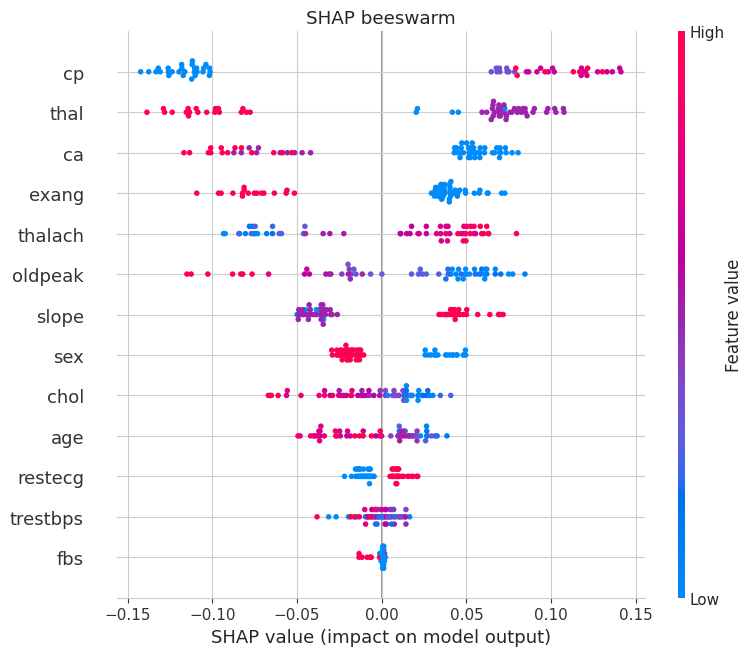

In [18]:
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP beeswarm')
plt.tight_layout()
plt.show()


### 7.3-Тапсырма. Жергілікті интерпретация — Waterfall Plot (10 балл)

Waterfall Plot — жекелеген болжамды белгілер бойынша бөліп көрсетеді. Базалық мәннен (E[f(x)]) бастап, әр белгі болжамды қалай өзгерткенін сатылап көрсетеді.

Waterfall үшін `shap.Explanation` объектісін қолданыңыз:
```python
explanation = shap.Explanation(
    values=shap_мәндері_бір_үлгі_үшін,
    base_values=explainer.expected_value[1],
    data=үлгі_деректері,
    feature_names=FEATURE_COLS
)
shap.waterfall_plot(explanation, show=False)
```

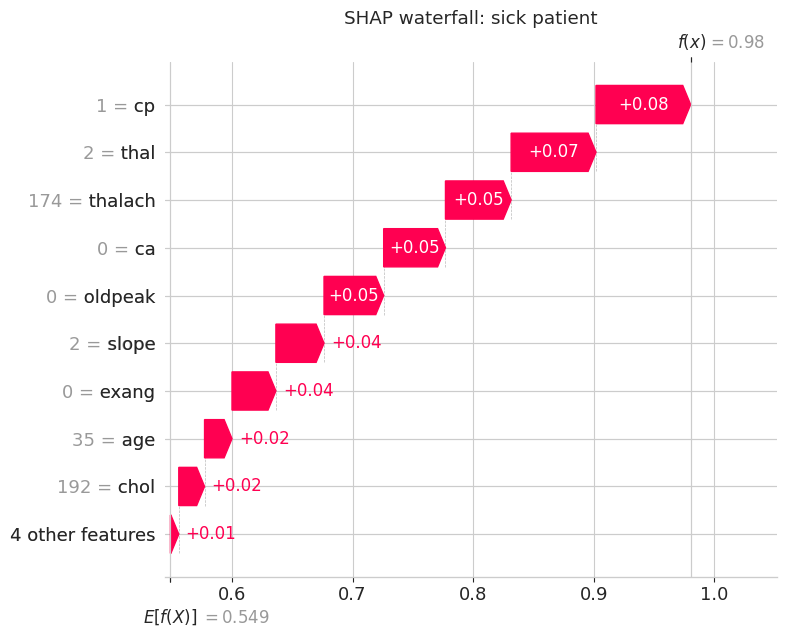

In [19]:
plt.figure(figsize=(12, 6))
shap_sick_all = explainer.shap_values(sample_sick)

if type(shap_sick_all) == list:
    shap_sick = shap_sick_all[1][0]
    base_value = explainer.expected_value[1]
else:
    shap_sick = shap_sick_all[0, :, 1]
    base_value = explainer.expected_value[1]

explanation_sick = shap.Explanation(
    values=shap_sick,
    base_values=base_value,
    data=sample_sick.values[0],
    feature_names=FEATURE_COLS
)

shap.waterfall_plot(explanation_sick, show=False)
plt.title('SHAP waterfall: sick patient')
plt.tight_layout()
plt.show()


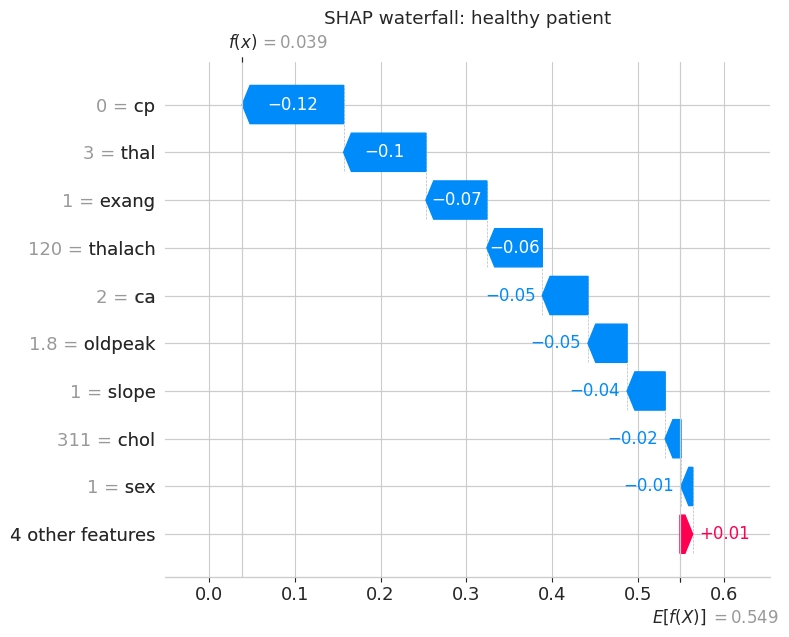

In [20]:
plt.figure(figsize=(12, 6))
shap_healthy_all = explainer.shap_values(sample_healthy)

if type(shap_healthy_all) == list:
    shap_healthy = shap_healthy_all[1][0]
    base_value = explainer.expected_value[1]
else:
    shap_healthy = shap_healthy_all[0, :, 1]
    base_value = explainer.expected_value[1]

explanation_healthy = shap.Explanation(
    values=shap_healthy,
    base_values=base_value,
    data=sample_healthy.values[0],
    feature_names=FEATURE_COLS
)

shap.waterfall_plot(explanation_healthy, show=False)
plt.title('SHAP waterfall: healthy patient')
plt.tight_layout()
plt.show()


**7.3 Explanation (5 points)**

1. For the sick patient, the strongest positive features were `cp`, `thal`, `thalach`, `ca`, and `oldpeak`.
2. For the healthy patient, the strongest negative features were `cp`, `thal`, `exang`, `thalach`, and `ca`.
3. The base value E[f(x)] is the average model output before the patient features are added. Each feature then moves the prediction up or down.


### 7.4-Тапсырма. Dependence Plot — Қосымша тапсырма (бонус 5 балл)

Dependence Plot — белгінің мәні мен оның SHAP мәнінің арасындағы байланысты көрсетеді. Екінші белгі өлшем ретінде боялады (интерактивті эффект).

<Figure size 1000x600 with 0 Axes>

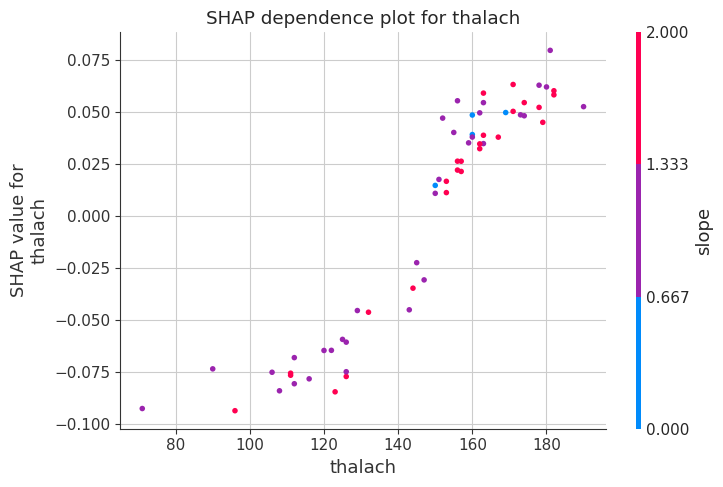

In [21]:
plt.figure(figsize=(10, 6))
shap.dependence_plot('thalach', shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP dependence plot for thalach')
plt.tight_layout()
plt.show()



## 8-Бөлім. LIME Әдісі (30 балл)

### LIME дегеніміз не?

LIME (Local Interpretable Model-agnostic Explanations) — кез келген «қара жәшік» модельді жергілікті деңгейде интерпретациялайды. Принципі: талдалатын нүктенің маңайында жасанды деректер жасап, оларға қарапайым сызықтық модель оқытады. Сол сызықтық модельдің коэффициенттері белгілердің жергілікті маңыздылығы болып табылады.

LIME SHAP-тан айырмашылығы — ол кез келген модель типімен жұмыс жасай алады (нейрондық желілер, SVM, т.б.).

**Пайдалы сілтемелер:**
- LIME GitHub: https://github.com/marcotcr/lime
- LIME мысалдары: https://lime-ml.readthedocs.io

### 8.1-Тапсырма. LIME Explainer жасау (5 балл)

Кестелік деректер үшін `lime.lime_tabular.LimeTabularExplainer` қолданылады.

In [22]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=FEATURE_COLS,
    class_names=['no disease', 'disease'],
    mode='classification',
    random_state=RANDOM_STATE
)

print("LIME ready")
print(len(FEATURE_COLS))


LIME ready
13


### 8.2-Тапсырма. Ауру БАР болжамы үшін LIME түсіндірмесі (10 балл)

In [23]:
lime_exp_sick = lime_explainer.explain_instance(
    data_row=sample_sick.values[0],
    predict_fn=model.predict_proba,
    num_features=10,
    num_samples=3000
)

print("LIME result for sick patient:")
for name, weight in lime_exp_sick.as_list(label=1):
    print(name, round(weight, 4))


LIME result for sick patient:
thal <= 2.00 0.1619
ca <= 0.00 0.1243
exang <= 0.00 0.1029
0.00 < cp <= 1.00 0.0901
1.00 < slope <= 2.00 0.077
oldpeak <= 0.00 0.0762
thalach > 166.00 0.0575
0.00 < sex <= 1.00 -0.0559
age <= 47.00 0.0351
chol <= 211.25 0.0336


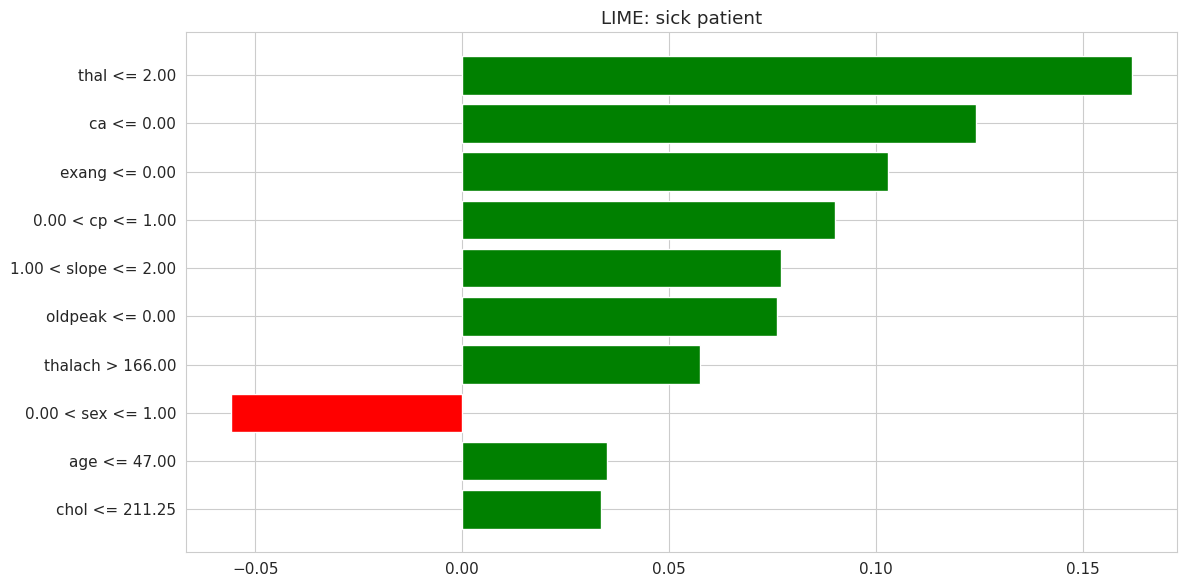

In [24]:
fig = lime_exp_sick.as_pyplot_figure(label=1)
fig.set_size_inches(12, 6)
plt.title('LIME: sick patient')
plt.tight_layout()
plt.show()


### 8.3-Тапсырма. Ауру ЖОҚ болжамы үшін LIME түсіндірмесі (10 балл)

LIME result for healthy patient:
cp <= 0.00 -0.1964
2.00 < thal <= 3.00 -0.1643
ca > 1.00 -0.1064
0.00 < exang <= 1.00 -0.0986
thalach <= 137.25 -0.0805
slope <= 1.00 -0.0748
chol > 273.75 -0.055
0.00 < sex <= 1.00 -0.0518
0.80 < oldpeak <= 1.80 -0.0269
age <= 47.00 0.0253


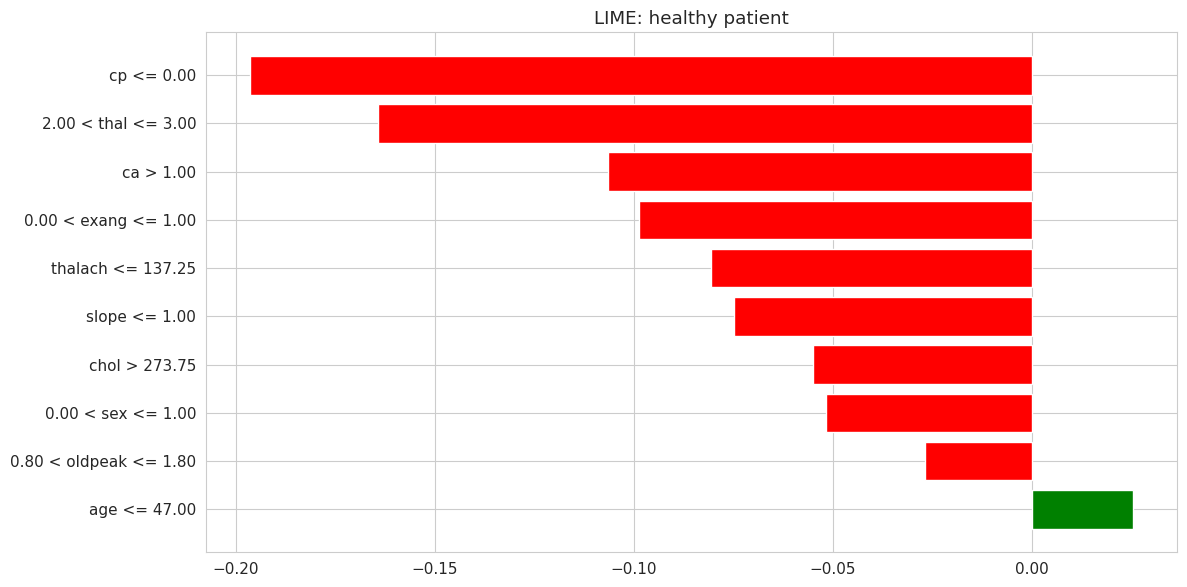

In [25]:
lime_exp_healthy = lime_explainer.explain_instance(
    data_row=sample_healthy.values[0],
    predict_fn=model.predict_proba,
    num_features=10,
    num_samples=3000
)

print("LIME result for healthy patient:")
for name, weight in lime_exp_healthy.as_list(label=1):
    print(name, round(weight, 4))

fig = lime_exp_healthy.as_pyplot_figure(label=1)
fig.set_size_inches(12, 6)
plt.title('LIME: healthy patient')
plt.tight_layout()
plt.show()


**8.3 Explanation (5 points)**

1. For the sick patient, LIME highlighted `thal`, `ca`, `exang`, `cp`, and `slope`.
2. For the healthy patient, `cp`, `thal`, `ca`, `exang`, and `thalach` were the main features pushing the prediction toward no disease.
3. Green bars support the selected class. Red bars work against it.




## 9-Бөлім. Салыстырмалы Талдау (15 балл)

**Мақсат:** SHAP және LIME нәтижелерін бір графикте салыстырып, олардың ұқсастықтары мен айырмашылықтарын анықтаңыз.

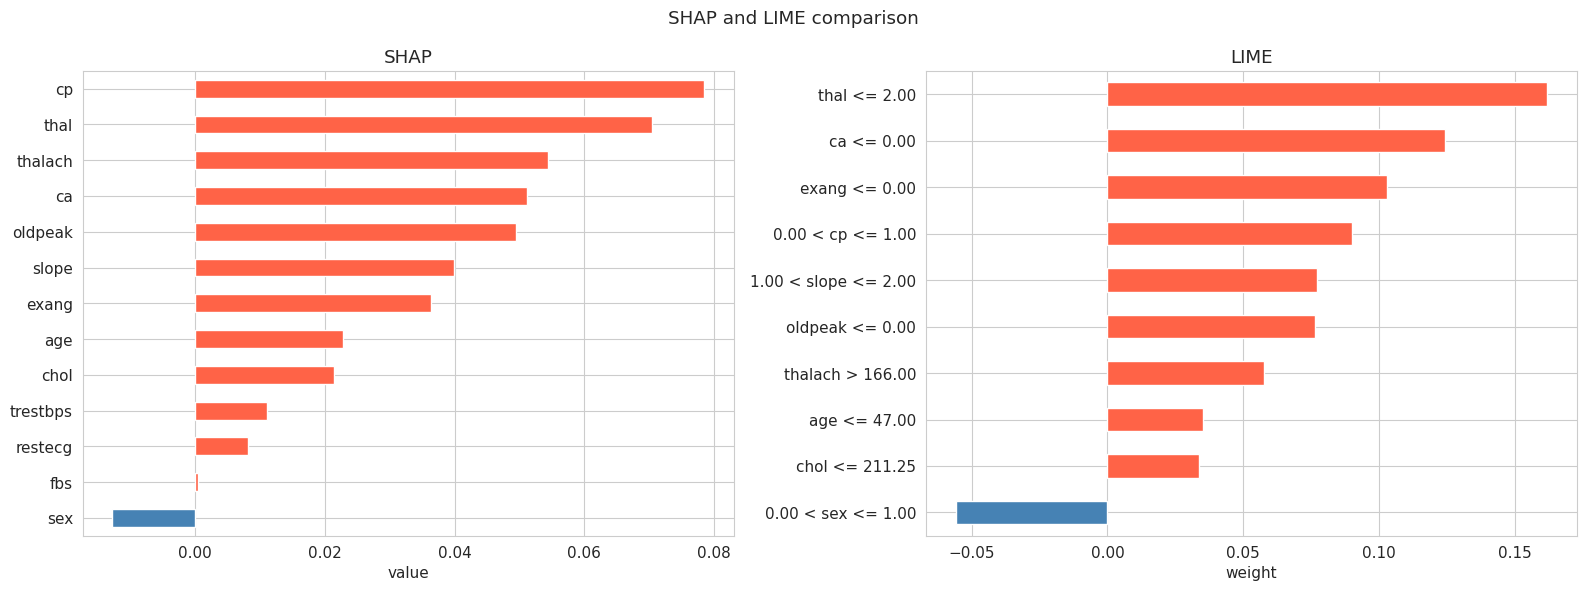

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

shap_sick_all = explainer.shap_values(sample_sick)
if type(shap_sick_all) == list:
    sv_sick = shap_sick_all[1][0]
else:
    sv_sick = shap_sick_all[0, :, 1]

shap_part = pd.Series(sv_sick, index=FEATURE_COLS).sort_values()
lime_part = pd.Series(dict(lime_exp_sick.as_list(label=1))).sort_values()

colors1 = ['tomato' if x > 0 else 'steelblue' for x in shap_part]
colors2 = ['tomato' if x > 0 else 'steelblue' for x in lime_part]

shap_part.plot(kind='barh', ax=axes[0], color=colors1)
axes[0].set_title('SHAP')
axes[0].set_xlabel('value')

lime_part.plot(kind='barh', ax=axes[1], color=colors2)
axes[1].set_title('LIME')
axes[1].set_xlabel('weight')

plt.suptitle('SHAP and LIME comparison')
plt.tight_layout()
plt.show()
